In [1]:
import matplotlib.pyplot as plt

import numpy as np
import xpart as xp
import xtrack as xt

from xnlbd.analyse.normal_forms import *
from xnlbd.track import Henonmap
from xnlbd.visualise.orbits import get_orbit_points

In [2]:
# Lattice and beam parameters
alpha_x = 0.0
beta_x = 1.0
alpha_y = 0.0
beta_y = 0.01

Qx1 = 0.2071   # horizontal tune
Qy1 = 0.2271   # vertical tune

K2 = 2.0       # sextupole strength
K3 = 0.0       # octupole strength

nemitt_x = 1           # horizontal normalised emittance
nemitt_y = 1   # vertical normalised emittance (quasi-1D)

In [3]:
# Build Henon map element and xtrack line
henon1 = Henonmap(
    omega_x=2 * np.pi * Qx1,
    omega_y=2 * np.pi * Qy1,
    twiss_params=[alpha_x, beta_x, alpha_y, beta_y],
    dqx=0.0,
    dqy=0.0,
    dx=0.0,
    ddx=0.0,
    multipole_coeffs=[K2, K3],
    norm=False,
)

drift1 = xt.Drift(length=0.0)  # zero-length drift required for aperture check

line1 = xt.Line(
    elements=[drift1, henon1],
    element_names=["zero_len_drift", "henon"],
)
line1.particle_ref = xt.Particles(mass0=xp.PROTON_MASS_EV)
line1.twiss_default["method"] = "4d"
line1.config.XTRACK_GLOBAL_XY_LIMIT = 1
line1.build_tracker()

Compiling ContextCpu kernels...


Done compiling ContextCpu kernels.


In [4]:
# Compute phase-space portrait in the horizontal plane (physical coords)
orbits1 = get_orbit_points(line1, element="henon", planes="H", 
                           num_pts=50, #TO BE CHECKED
                           nemitt_x=1, nemitt_y=1)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


/mnt/hdd1/sterbini/IPAC2026_NL_matching/miniconda/lib/python3.13/site-packages/xtrack/particles/particles.py:1729: RuntimeWarning: invalid value encountered in divide
  pzeta = self.ptau / self.beta0


(np.float64(-0.9262211652484228),
 np.float64(1.0424812049107581),
 np.float64(-0.9314908028562509),
 np.float64(0.8841006322377222))

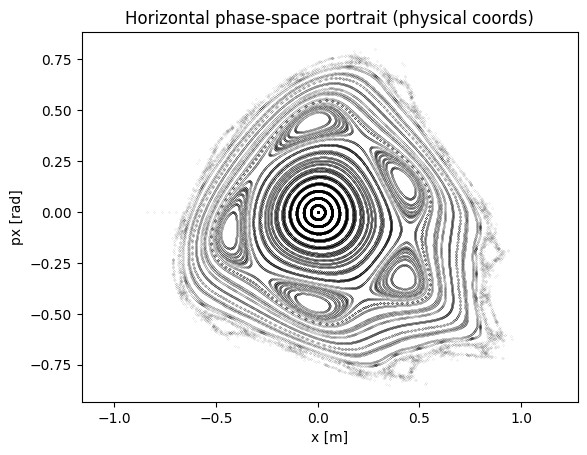

In [5]:
# Plot portrait in physical (x, px) coordinates
plt.figure()
plt.plot(
    orbits1["H_orbit_points"]["x"],
    orbits1["H_orbit_points"]["px"],
    color="black",
    marker=".",
    markersize=0.1,
    linestyle="None",
)
plt.xlabel("x [m]")
plt.ylabel("px [rad]")
plt.title("Horizontal phase-space portrait (physical coords)")
plt.axis("equal")

(np.float64(-0.9562034413552183),
 np.float64(1.0762268808837274),
 np.float64(-0.9616436599599708),
 np.float64(0.9127194440901097))

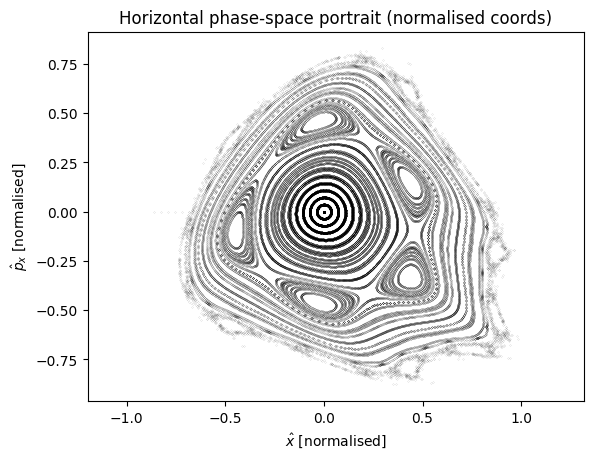

In [6]:
# Plot portrait in normalised (x_norm, px_norm) coordinates
plt.figure()
plt.plot(
    orbits1["H_orbit_points_norm"]["x_norm"],
    orbits1["H_orbit_points_norm"]["px_norm"],
    color="black",
    marker=".",
    markersize=0.1,
    linestyle="None",
)
plt.xlabel(r"$\hat{x}$ [normalised]")
plt.ylabel(r"$\hat{p}_x$ [normalised]")
plt.title("Horizontal phase-space portrait (normalised coords)")
plt.axis("equal")

In [7]:
# Compute the one-turn map and normal form via PolyLine4D
poly_line1 = PolyLine4D(
    line1,
    line1.particle_ref,
    max_ele_order=2, #TO CHECK
    max_map_order=2, #TO CHECK
    nemitt_x=nemitt_x,
    nemitt_y=nemitt_y,
)
poly_line1.calculate_one_turn_map()
poly_line1.calculate_normal_form(
    max_nf_order=10, #5,
    # res_space_dim=1,
    res_space_dim=0,
    res_case=0,
    # res_case=2,
    # res_basis1=[5, 0],
    # res_eig=[np.exp(1j * 2*np.pi*0.2),
    #         np.exp(-1j * 2*np.pi*0.2),
    #         np.exp(1j * 2*np.pi*0.2271),
    #         np.exp(-1j * 2*np.pi*0.2271),],
)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Combining line elements: 100.00%
Combination of all line elements finished!


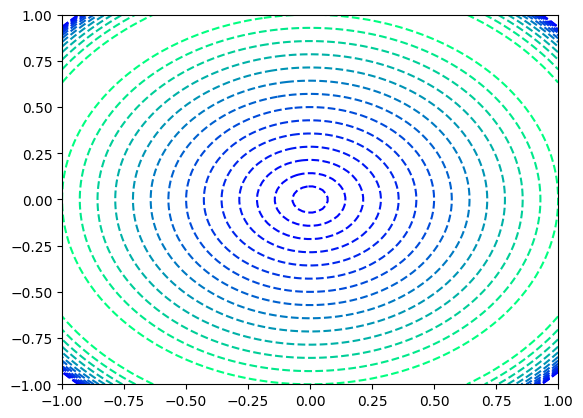

In [8]:
zeta1_re1 = np.linspace(-1,1, 100)
zeta1_im1 = np.linspace(-1, 1, 100)
zeta2_re1 = np.zeros(100)
zeta2_im1 = np.zeros(100)
Zeta1_re1, Zeta1_im1 = np.meshgrid(zeta1_re1, zeta1_im1)
Zeta2_re1, Zeta2_im1 = np.meshgrid(zeta2_re1, zeta2_im1)
H_values1 = poly_line1.normal_form.H.substitute(
    Zeta1_re1 + 1j * Zeta1_im1,
    Zeta1_re1 - 1j * Zeta1_im1,
    Zeta2_re1 + 1j * Zeta2_im1,
    Zeta2_re1 - 1j * Zeta2_im1,
)
H_values1 = np.imag(H_values1)
zeta1_re_level1 = np.linspace(0, 1.0, 15)
zeta1_im_level1 = np.zeros(15)
zeta2_re_level1 = np.zeros(15)
zeta2_im_level1 = np.zeros(15)
H_levels1 = poly_line1.normal_form.H.substitute(
    zeta1_re_level1 + 1j * zeta1_im_level1,
    zeta1_re_level1 - 1j * zeta1_im_level1,
    zeta2_re_level1 + 1j * zeta2_im_level1,
    zeta2_re_level1 - 1j * zeta2_im_level1,
)
H_levels1 = np.imag(H_levels1)
contour = plt.contour(
        Zeta1_re1,
        -Zeta1_im1,
        H_values1,
        levels=np.sort(H_levels1),
        linestyles="--",
        cmap="winter",
    )

/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1056: ComplexWarning: Casting complex values to real discards the imaginary part
  x_norm = np.asarray((complex_norm[0] + complex_norm[1]) / 2.0, dtype=float)
/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1057: ComplexWarning: Casting complex values to real discards the imaginary part
  px_norm = np.asarray(
/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1060: ComplexWarning: Casting complex values to real discards the imaginary part
  y_norm = np.asarray((complex_norm[2] + complex_norm[3]) / 2.0, dtype=float)
/mnt/hdd1/sterbini/IPAC2026_NL_matching/xnlbd/xnlbd/analyse/normal_forms/numeric_normal_forms.py:1061: ComplexWarning: Casting complex values to real discards the imaginary part
  py_norm = np.asarray(


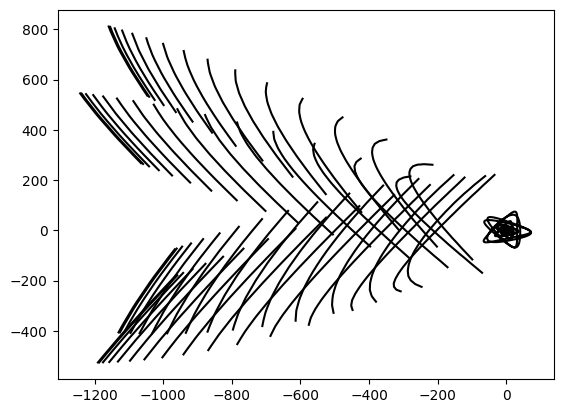

In [9]:
segments = contour.allsegs

x = []
y = []

for seg in segments:
     for subseg in seg:
         curr_x = []
         curr_y = []
         for coord in subseg:
             curr_x.append(coord[0])
             curr_y.append(coord[1])
         x.append(curr_x)
         y.append(curr_y)
         
# FOR EACH ELEMENT IN THE TRACKING LIST, PLOT THE TUNE SHIFT AND COMPARE WITH NORMAL-FORM PREDICTIONT OF
for xx, yy in zip(x, y):
    zeta1=np.array(xx) + 1j*np.array(yy)
    zeta1_star = np.conj(zeta1)
    zeta2 = np.zeros_like(zeta1)
    zeta2_star = np.zeros_like(zeta1)
    aux = poly_line1.normal_form.nf_to_norm(zeta1, zeta1_star, zeta2, zeta2_star)
    plt.plot(
        np.real(aux[0]),
        np.real(aux[1]),
        color="black",
        linestyle="-",
        #label="Normal form" if Ix == 0 else None,
    )
 
    
    

(np.float64(-0.9262211652484228),
 np.float64(1.0424812049107581),
 np.float64(-0.9314908028562509),
 np.float64(0.8841006322377222))

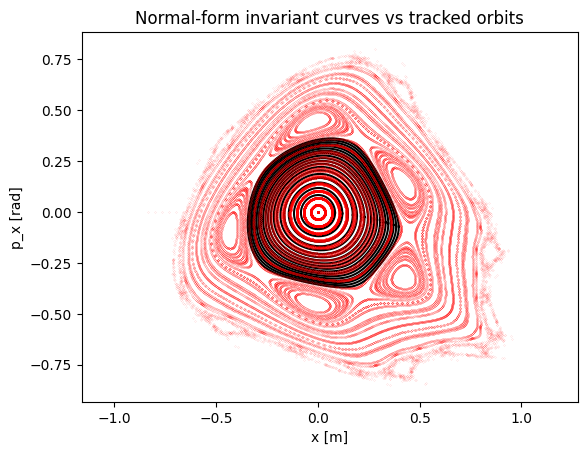

In [11]:
# Overlay normal-form invariant curves on top of tracked orbits
plt.figure()
for Ix in np.linspace(0,0.06671656, 20):
    theta_x = np.linspace(0, 2 * np.pi, 200)
    # Complex normal-form coordinates for a circle of action Ix
    zeta_1 = np.sqrt(2 * Ix) * np.exp(1j * theta_x)
    zeta_1_conj = np.conjugate(zeta_1)
    zeta_2 = np.zeros_like(zeta_1)
    zeta_2_conj = np.zeros_like(zeta_1)
    # Map from normal-form to physical normalised coordinates
    aux = poly_line1.normal_form.nf_to_norm(zeta_1, zeta_1_conj, zeta_2, zeta_2_conj)
    plt.plot(
        np.real(aux[0]),
        np.real(aux[1]),
        color="black",
        linestyle="-",
        #label="Normal form" if Ix == 0 else None,
    )

plt.plot(
    orbits1["H_orbit_points"]["x"],
    orbits1["H_orbit_points"]["px"],
    color="red",
    marker=".",
    markersize=0.1,
    linestyle="None",
    label="Tracked orbits",
)
plt.xlabel("x [m]")
plt.ylabel("p_x [rad]")
plt.title("Normal-form invariant curves vs tracked orbits")
plt.axis("equal")

In [74]:
poly_line1.normal_form.H.terms

[Term(coeff=np.complex128(-3.854978599827393e-18+1.4269113832604838j), x_exp=0, px_exp=0, y_exp=1, py_exp=1),
 Term(coeff=np.complex128(1.012429148529085e-16+1.3012476771168924j), x_exp=1, px_exp=1, y_exp=0, py_exp=0),
 Term(coeff=np.complex128(8.382800542867792e-22-1.079441216121959e-05j), x_exp=0, px_exp=0, y_exp=2, py_exp=2),
 Term(coeff=np.complex128(-3.13515875862475e-19+0.0030761655197355806j), x_exp=1, px_exp=1, y_exp=1, py_exp=1),
 Term(coeff=np.complex128(1.00325080275992e-17-0.10381222302167499j), x_exp=2, px_exp=2, y_exp=0, py_exp=0),
 Term(coeff=np.complex128(-2.7287762183814427e-24+3.214017374812874e-08j), x_exp=0, px_exp=0, y_exp=3, py_exp=3),
 Term(coeff=np.complex128(1.632895186783724e-21-4.184669108791671e-06j), x_exp=1, px_exp=1, y_exp=2, py_exp=2),
 Term(coeff=np.complex128(0.0007890671908435559j), x_exp=2, px_exp=2, y_exp=1, py_exp=1),
 Term(coeff=np.complex128(3.3441693425330667e-18-0.02065186198063092j), x_exp=3, px_exp=3, y_exp=0, py_exp=0),
 Term(coeff=np.comple

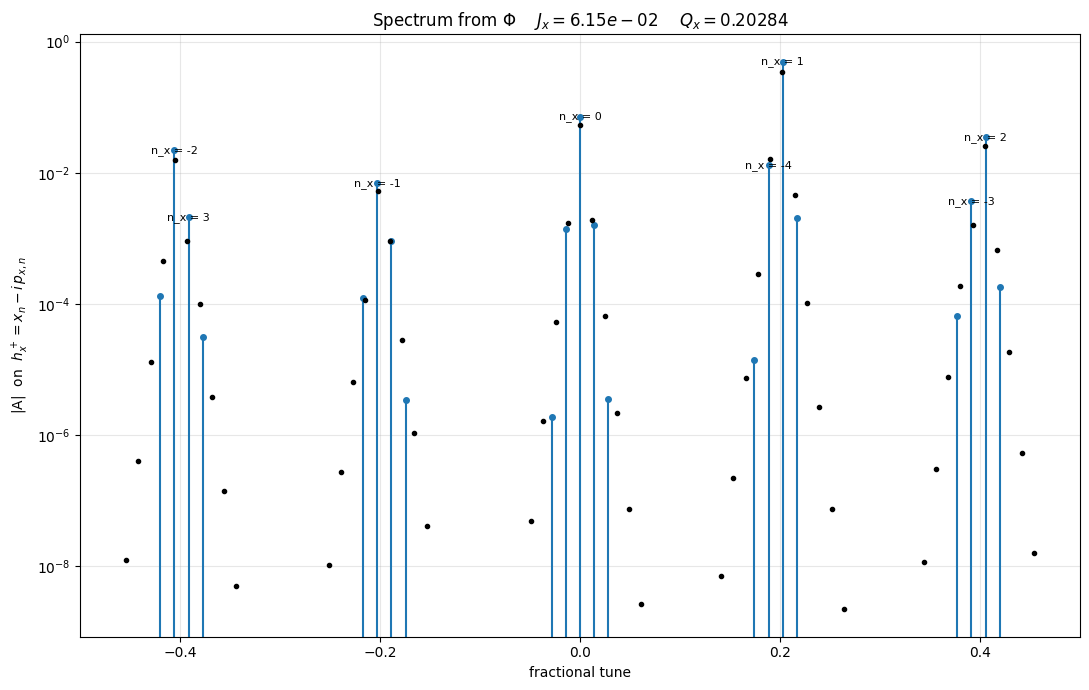

In [16]:
import pickle
with open('../data/henon_tracking_list.pkl', 'rb') as f:
    tracking_list = pickle.load(f)
with open('../data/henon_tori.pkl', 'rb') as f:
    tori = pickle.load(f)
    
"""
Plot the amplitude spectrum predicted by Phi at given (Jx, Jy).
No tracking, no NAFF.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

my_torus_index = 14
# ===== INPUTS =====
Jx = tori[my_torus_index].Ix   # [m·rad]
Jy = 0.0  # [m·rad]
n_label = 8     # how many top lines to annotate

# ===== TUNE WITH AMPLITUDE DETUNING (from diagonal H) =====
def amplitude_tunes(H, Qx0_frac, Qy0_frac, Jx, Jy):
    rows = [(t.x_exp, t.y_exp, complex(t.coeff)) for t in H.terms
            if t.x_exp == t.px_exp and t.y_exp == t.py_exp]
    df = (pd.DataFrame(rows, columns=["j", "l", "c"])
            .groupby(["j", "l"], as_index=False).sum())
    c10 = df.query("j==1 and l==0")["c"].iloc[0].imag
    c01 = df.query("j==0 and l==1")["c"].iloc[0].imag
    kx, ky = Qx0_frac / c10, Qy0_frac / c01
    Qx = kx * sum(r.c.imag * r.j * (2*Jx)**(r.j-1) * (2*Jy)**r.l
                  for r in df.itertuples() if r.j >= 1)
    Qy = ky * sum(r.c.imag * r.l * (2*Jx)**r.j * (2*Jy)**(r.l-1)
                  for r in df.itertuples() if r.l >= 1)
    return Qx, Qy

# ===== SPECTRUM FROM A LINEAR COMBO OF POLYNOMS =====
def combine_polys(*polys_factors):
    """Sum  factor_i * poly_i  aligned by monomial -> dict (j,k,l,m): coeff."""
    out = defaultdict(lambda: 0 + 0j)
    for poly, factor in polys_factors:
        for t in poly.terms:
            out[(t.x_exp, t.px_exp, t.y_exp, t.py_exp)] += factor * complex(t.coeff)
    return out

def poly_to_dict(poly):
    """Polynom -> dict {(j,k,l,m): coeff}"""
    out = defaultdict(lambda: 0 + 0j)
    for t in poly.terms:
        out[(t.x_exp, t.px_exp, t.y_exp, t.py_exp)] += complex(t.coeff)
    return out

def spectrum(poly_dict, Jx, Jy, atol=1e-30):
    """Group by (nx, ny) = (j-k, l-m) and sum complex amplitudes."""
    spec = defaultdict(lambda: 0 + 0j)
    for (j, k, l, m), c in poly_dict.items():
        spec[(j - k, l - m)] += c * (2*Jx)**((j + k) / 2) * (2*Jy)**((l + m) / 2)
    df = pd.DataFrame([{"nx": nx, "ny": ny, "A": A, "abs_A": abs(A)}
                       for (nx, ny), A in spec.items()])
    return (df[df["abs_A"] > atol]
              .sort_values("abs_A", ascending=False)
              .reset_index(drop=True))

# ===== COMPUTE =====
nf, tw = poly_line1.normal_form, poly_line1.tw
Qx0, Qy0 = tw.qx % 1, tw.qy % 1
Qx, Qy   = amplitude_tunes(nf.H, Qx0, Qy0, Jx, Jy)

# Complex one-sided signals: h+_x = x_norm - i px_norm,  h+_y = y_norm - i py_norm
hxp = poly_to_dict(nf.Phi.x_poly)
hyp = poly_to_dict(nf.Phi.y_poly)

spec_x = spectrum(hxp, Jx, Jy)
spec_y = spectrum(hyp, Jx, Jy)
# wrap to [-0.5, 0.5)  instead of [0, 1)
for s in (spec_x, spec_y):
    s["freq"] = ((s["nx"] * Qx + s["ny"] * Qy + 0.5) % 1) - 0.5



# ===== PLOT =====
fig, axes = plt.subplots(1, 1, figsize=(11, 7), sharex=True)
for ax, spec, label in zip(
        [axes], [spec_x],
        [r"$h_x^+ = x_n - i\,p_{x,n}$", r"$h_y^+ = y_n - i\,p_{y,n}$"]):
    ml, sl, bl = ax.stem(spec["freq"], spec["abs_A"]*np.sqrt(2), basefmt=" ")
    plt.setp(ml, markersize=4)
    for r in spec.head(n_label).itertuples():
        ax.annotate(f"n_x = {r.nx}", (r.freq, r.abs_A),
                    fontsize=8, ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points")
    ax.set_yscale("log")
    ax.set_ylabel(f"|A|  on  {label}")
    ax.grid(alpha=0.3)

axes.semilogy(tracking_list[my_torus_index]['Qx'], np.abs(tracking_list[my_torus_index]['Ax']), '.', color='k', ms=6, alpha=1)

axes.set_title(rf"Spectrum from $\Phi$    "
                  rf"$J_x={Jx:.2e}$    "
                  rf"$Q_x={Qx:.5f}$")
axes.set_xlabel("fractional tune")
axes.set_xlim(-0.5, 0.5)
plt.tight_layout()
plt.show()

In [63]:
tori[14].Ix

np.float64(0.061476152835363077)

In [12]:
# import data/henon_tracking_list.pkl
import pickle
with open('../data/henon_tracking_list.pkl', 'rb') as f:
    tracking_list = pickle.load(f)
with open('../data/henon_tori.pkl', 'rb') as f:
    tori = pickle.load(f)
    

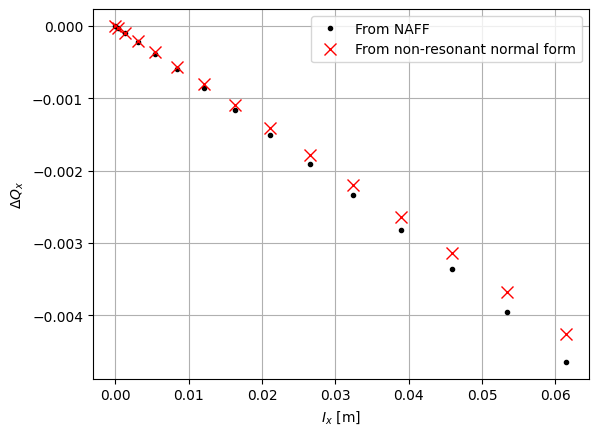

In [19]:
nf, tw = poly_line1.normal_form, poly_line1.tw

Qx0, Qy0 = tw.qx % 1, tw.qy % 1

for i, t in enumerate(tracking_list[0:15]):
    plt.plot(tori[i].Ix, t['Qx'][0]-Qx0, '.', color='k', ms=6, alpha=1, label=f'From NAFF' if i==0 else None)
    Qx, Qy   = amplitude_tunes(nf.H, Qx0, Qy0, tori[i].Ix, 0)
    plt.plot(tori[i].Ix, (Qx-Qx0), 'x', color='red', ms=8, label='From non-resonant normal form' if i==0 else None)
plt.grid()
plt.xlabel(r'$I_x$ [m]')
plt.ylabel(r'$\Delta Q_x$')
plt.legend()